#### As stated in the project introduction, the project aims to answer several questions geared towards finding demographic and economic relationships in states and counties using the US Census data.

In [10]:
import os
import pandas as pd
import re
from sqlalchemy import create_engine, URL
import psycopg
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
load_dotenv()

DB_CONFIG = {
    "dbname":   os.getenv("DB_NAME",   "census_project"),
    "user":     os.getenv("DB_USER",     "project_gmt"),
    "password": os.getenv("DB_PASSWORD"),
    "host":     os.getenv("DB_HOST",     "localhost"),
    "port":     int(os.getenv("DB_PORT", "5432")),
}

url = URL.create(
    "postgresql+psycopg",
    username=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"],
    database=DB_CONFIG["dbname"],
)

engine = create_engine(url, echo=False)

##### Several queries to analyse and provide answers to questions to the above are below....
---

##### Is there a relationship between population growth and economic performance?

Answer: There is a weak positive relationship between population and income, and essentially no strong relationship between population and poverty or unemployment in this dataset. Larger population have higher median household income but with a weak relationship.

In [11]:
query_1 = f"""
SELECT
  corr(population, median_household_income) AS corr_population_income,
  corr(population, poverty_rate) AS corr_population_poverty,
  corr(population, unemployment_rate) AS corr_population_unemployment
FROM cleaned_us_census_data;
"""

rq1 = pd.read_sql(query_1, engine)

print("\nRelationship between population growth and economic performance - ")
print(rq1.head())



Relationship between population growth and economic performance - 
   corr_population_income  corr_population_poverty  \
0                0.284639                -0.086479   

   corr_population_unemployment  
0                       0.05066  


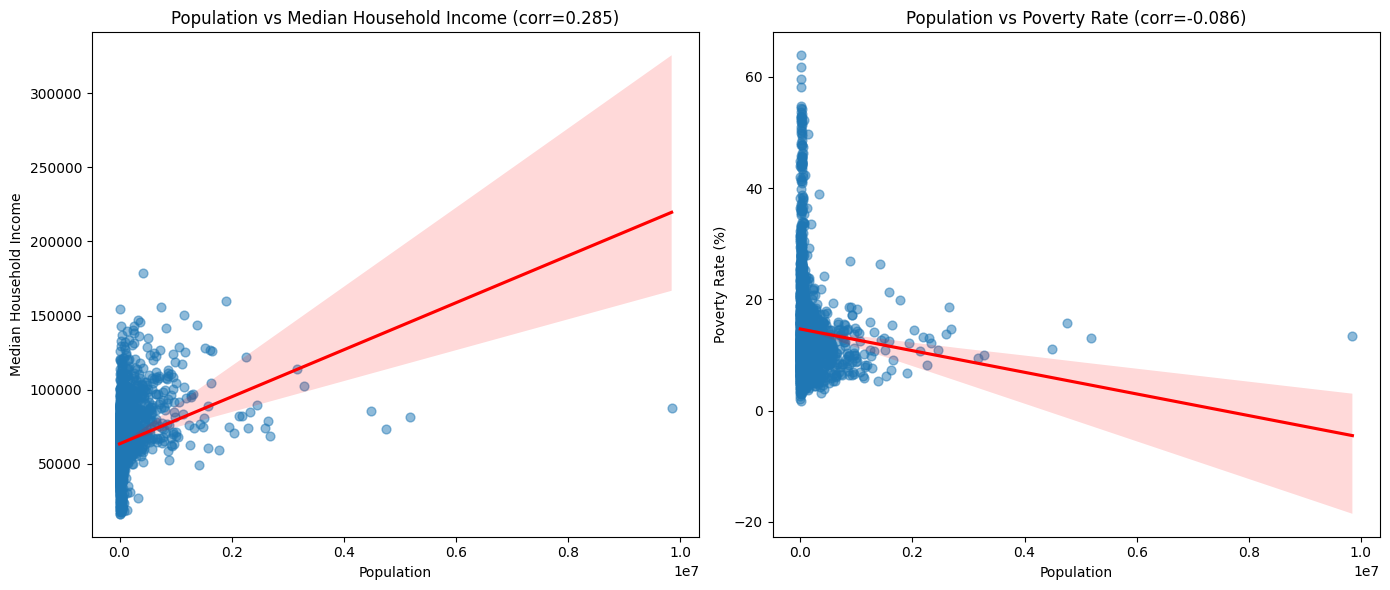

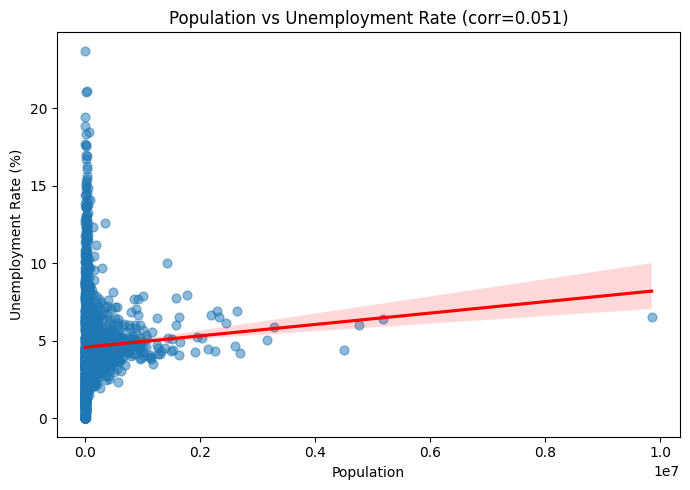

In [14]:
query_pop = f"""
SELECT
  population,
  median_household_income,
  poverty_rate,
  unemployment_rate
FROM cleaned_us_census_data;
"""
pop_df = pd.read_sql(query_pop, engine)
corr_values_pop = pop_df[['population', 'median_household_income', 'poverty_rate', 'unemployment_rate']].corr()['population']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(
    x='population',
    y='median_household_income',
    data=pop_df,
    ax=axes[0],
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
axes[0].set_title(f'Population vs Median Household Income (corr={corr_values_pop["median_household_income"]:.3f})')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Median Household Income')

sns.regplot(
    x='population',
    y='poverty_rate',
    data=pop_df,
    ax=axes[1],
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
axes[1].set_title(f'Population vs Poverty Rate (corr={corr_values_pop["poverty_rate"]:.3f})')
axes[1].set_xlabel('Population')
axes[1].set_ylabel('Poverty Rate (%)')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    x='population',
    y='unemployment_rate',
    data=pop_df,
    ax=ax,
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
ax.set_title(f'Population vs Unemployment Rate (corr={corr_values_pop["unemployment_rate"]:.3f})')
ax.set_xlabel('Population')
ax.set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

#### How does educational attainment affect median household income and employment levels?

Answer: 
1. Higher bachelor’s-degree attainment is evidently linked to higher income, but it does not show a meaningful effect on normalized employment or unemployment rates. 
2. The very strong correlations with raw employed/unemployed counts reflect population scale rather than a direct rate-based employment effect.

In [12]:
query_2 = f"""
SELECT
  corr(bachelors_degree, median_household_income) AS corr_education_income,
  corr(bachelors_degree, employed_population) AS corr_education_employment,
  corr(bachelors_degree, unemployed_population) AS corr_education_unemployment,
  corr(bachelors_degree, employment_rate) AS corr_education_employment_rate,
  corr(bachelors_degree, unemployment_rate) AS corr_education_unemployment_rate
FROM cleaned_us_census_data;
"""
rq2 = pd.read_sql(query_2, engine)

print("\nRelationship between education level and economic outcomes - ")
print(rq2.head())


Relationship between education level and economic outcomes - 
   corr_education_income  corr_education_employment  \
0               0.327477                   0.987661   

   corr_education_unemployment  corr_education_employment_rate  \
0                     0.953503                       -0.032639   

   corr_education_unemployment_rate  
0                          0.032639  


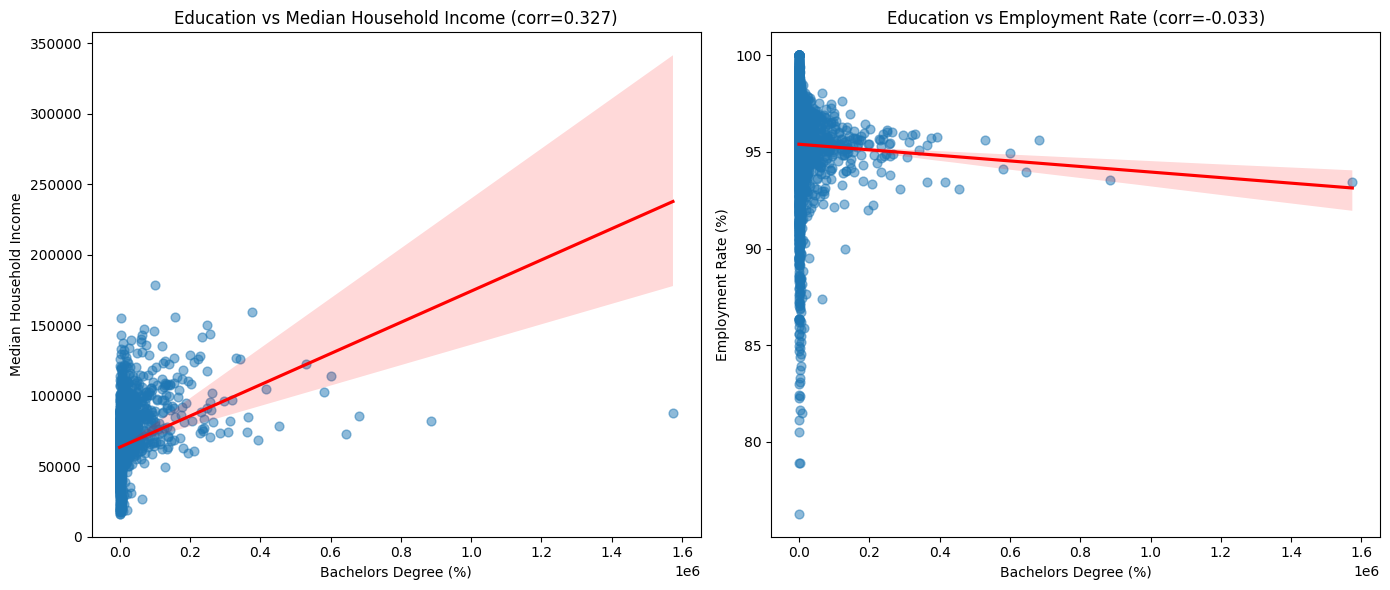

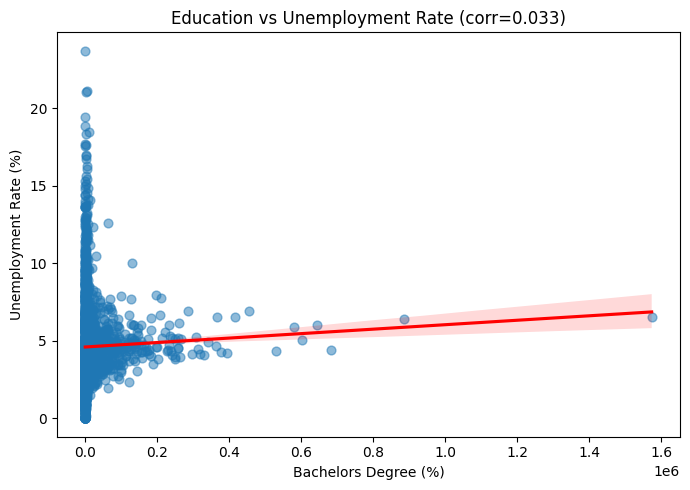

In [13]:
query_edu = f"""
SELECT
  bachelors_degree,
  median_household_income,
  employment_rate,
  unemployment_rate
FROM cleaned_us_census_data;
"""
edu_df = pd.read_sql(query_edu, engine)

corr_values = edu_df[['bachelors_degree', 'median_household_income', 'employment_rate', 'unemployment_rate']].corr()['bachelors_degree']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(
    x='bachelors_degree',
    y='median_household_income',
    data=edu_df,
    ax=axes[0],
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
axes[0].set_title(f'Education vs Median Household Income (corr={corr_values["median_household_income"]:.3f})')
axes[0].set_xlabel('Bachelors Degree (%)')
axes[0].set_ylabel('Median Household Income')

sns.regplot(
    x='bachelors_degree',
    y='employment_rate',
    data=edu_df,
    ax=axes[1],
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
axes[1].set_title(f'Education vs Employment Rate (corr={corr_values["employment_rate"]:.3f})')
axes[1].set_xlabel('Bachelors Degree (%)')
axes[1].set_ylabel('Employment Rate (%)')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    x='bachelors_degree',
    y='unemployment_rate',
    data=edu_df,
    ax=ax,
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)
ax.set_title(f'Education vs Unemployment Rate (corr={corr_values["unemployment_rate"]:.3f})')
ax.set_xlabel('Bachelors Degree (%)')
ax.set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

#### Which states or counties experience the highest economic growth trends?

The query computes an `economic_score` for each county using median household income and employment performance, and penalizes higher poverty and unemployment rates. 
It then ranks locations by this composite score and returns the top 5 and bottom 5 counties or states for economic growth trends.

In [27]:
query_growth_trends = f"""
SELECT
  countystate_name,
  median_household_income,
  employment_rate,
  poverty_rate,
  unemployment_rate,
  (median_household_income
    + 1000.0 * employment_rate
    - 500.0 * poverty_rate
    - 500.0 * unemployment_rate) AS economic_score
FROM cleaned_us_census_data
ORDER BY economic_score DESC
LIMIT 10;
"""
growth_trends_df = pd.read_sql(query_growth_trends, engine)
print("Highest economic growth trend locations:")
print(growth_trends_df)

Highest economic growth trend locations:
                 countystate_name  median_household_income  employment_rate  \
0            Kenedy County, Texas                      NaN       100.000000   
1        Esmeralda County, Nevada                      NaN        97.256858   
2        Loudoun County, Virginia                 178707.0        96.867250   
3  Santa Clara County, California                 159674.0        95.728865   
4    San Mateo County, California                 156000.0        95.719036   
5     Falls Church city, Virginia                 154734.0        94.053013   
6        Fairfax County, Virginia                 150113.0        96.147065   
7         Howard County, Maryland                 146982.0        96.509553   
8        Douglas County, Colorado                 145737.0        96.571066   
9   Los Alamos County, New Mexico                 143188.0        97.889280   

   poverty_rate  unemployment_rate  economic_score  
0      5.769231           0.000000  

C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\417775768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


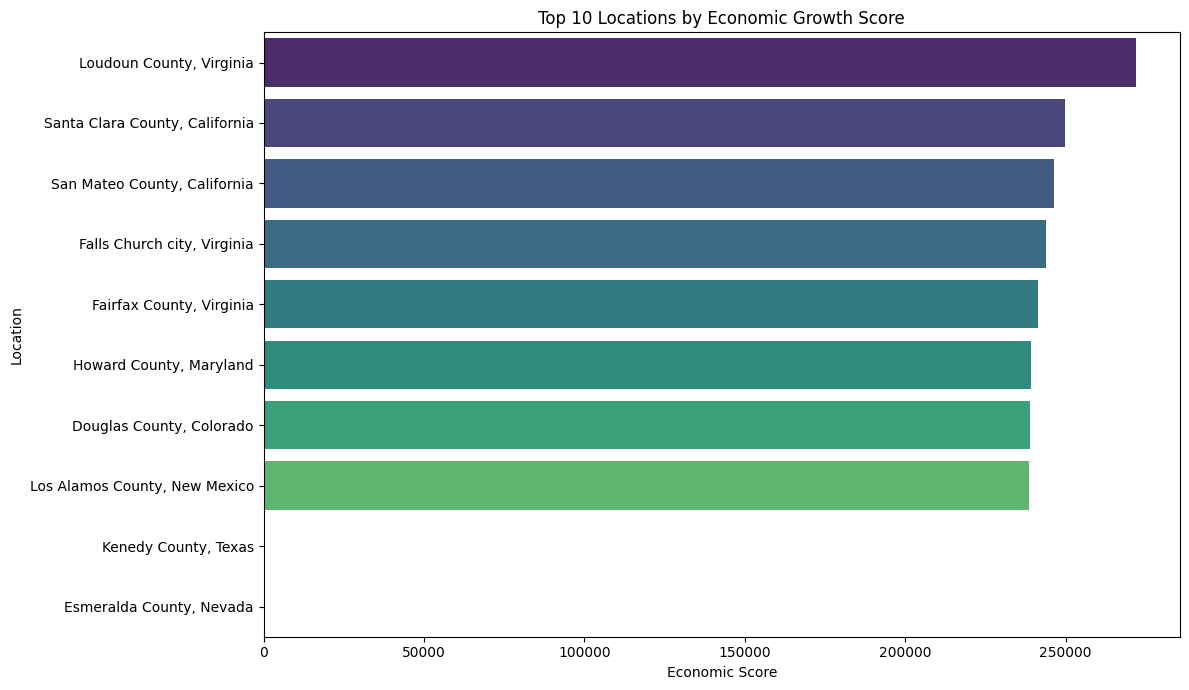

C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\417775768.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="median_household_income", y="countystate_name", data=top_growth_df, ax=axes[0, 0], palette="rocket")
C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\417775768.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="employment_rate", y="countystate_name", data=top_growth_df, ax=axes[0, 1], palette="mako")
C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\417775768.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="p

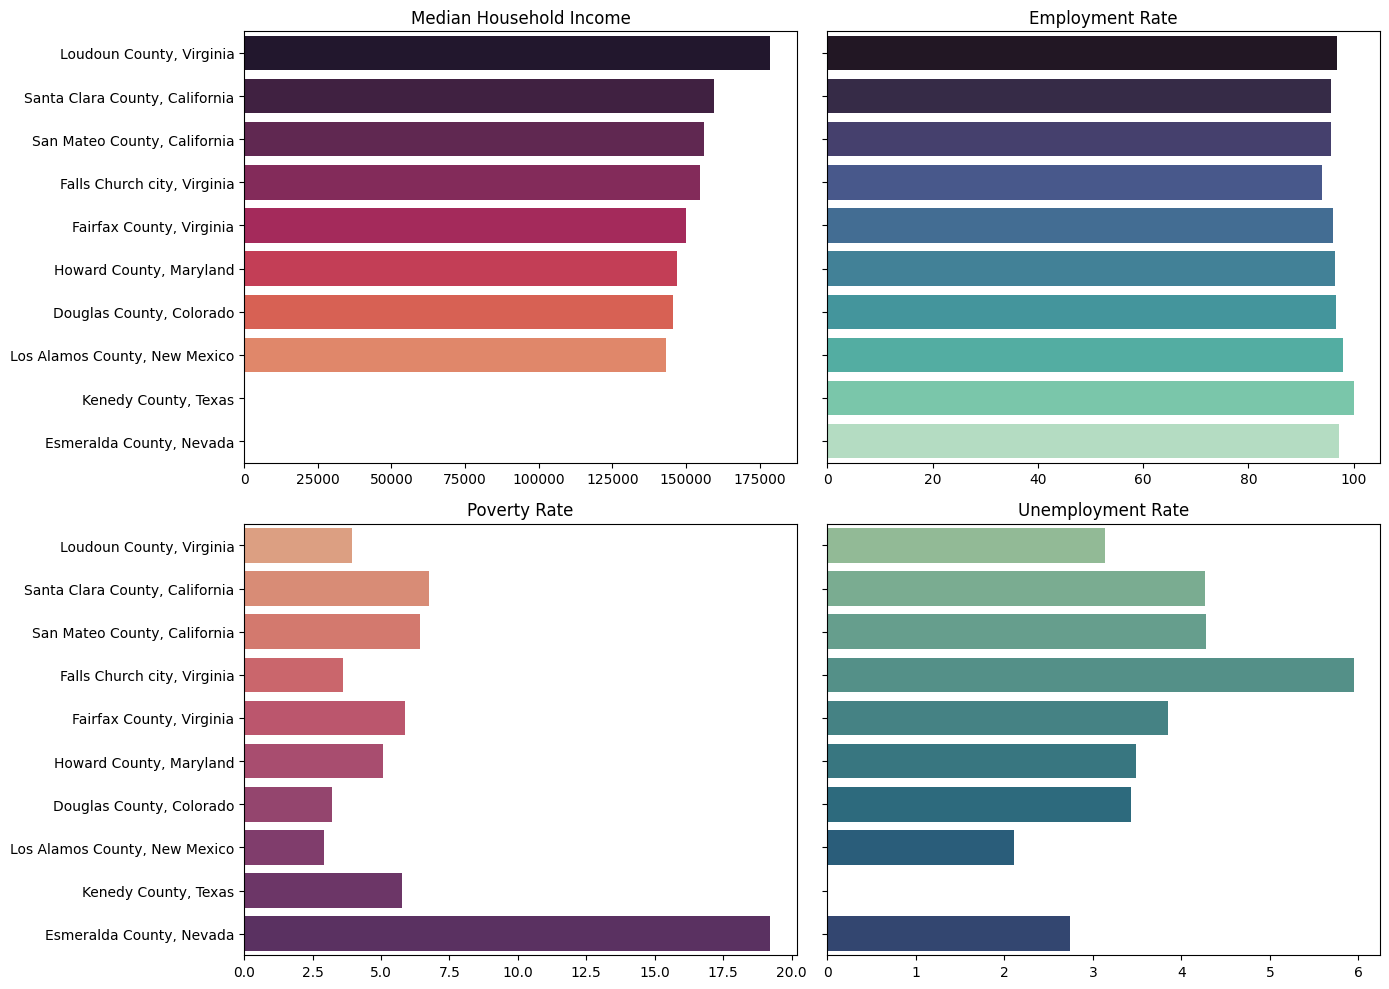

In [31]:
top_growth_df = pd.read_sql(query_growth_trends, engine)

top_growth_df = top_growth_df.sort_values("economic_score", ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
x="economic_score",
y="countystate_name",
data=top_growth_df,
palette="viridis",
ax=ax
)
ax.set_title("Top 10 Locations by Economic Growth Score")
ax.set_xlabel("Economic Score")
ax.set_ylabel("Location")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
sns.barplot(x="median_household_income", y="countystate_name", data=top_growth_df, ax=axes[0, 0], palette="rocket")
axes[0, 0].set_title("Median Household Income")
sns.barplot(x="employment_rate", y="countystate_name", data=top_growth_df, ax=axes[0, 1], palette="mako")
axes[0, 1].set_title("Employment Rate")
sns.barplot(x="poverty_rate", y="countystate_name", data=top_growth_df, ax=axes[1, 0], palette="flare")
axes[1, 0].set_title("Poverty Rate")
sns.barplot(x="unemployment_rate", y="countystate_name", data=top_growth_df, ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Unemployment Rate")

for axis in axes.flatten():
    axis.set_xlabel("")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()


#### Which states or counties experience the lowest economic growth trends?

In [28]:
query_growth_trends_low = f"""
SELECT
  countystate_name,
  median_household_income,
  employment_rate,
  poverty_rate,
  unemployment_rate,
  (median_household_income
    + 1000.0 * employment_rate
    - 500.0 * poverty_rate
    - 500.0 * unemployment_rate) AS economic_score
FROM cleaned_us_census_data
ORDER BY economic_score ASC
LIMIT 10;
"""
growth_trends_df = pd.read_sql(query_growth_trends_low, engine)
print("Lowest economic growth trend locations:")
print(growth_trends_df)

Lowest economic growth trend locations:
                    countystate_name  median_household_income  \
0      Gunica Municipio, Puerto Rico                  16210.0   
1      Utuado Municipio, Puerto Rico                  17624.0   
2    Adjuntas Municipio, Puerto Rico                  18605.0   
3     Mayagez Municipio, Puerto Rico                  17963.0   
4       Lajas Municipio, Puerto Rico                  18920.0   
5      Jayuya Municipio, Puerto Rico                  18413.0   
6     Florida Municipio, Puerto Rico                  21213.0   
7      Comero Municipio, Puerto Rico                  17254.0   
8  Guayanilla Municipio, Puerto Rico                  21400.0   
9     Maunabo Municipio, Puerto Rico                  19363.0   

   employment_rate  poverty_rate  unemployment_rate  economic_score  
0        78.926864     63.877582          21.073136    52661.504838  
1        78.896211     53.240608          21.103789    59348.012323  
2        82.379260     61.791377  

C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\3189926629.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


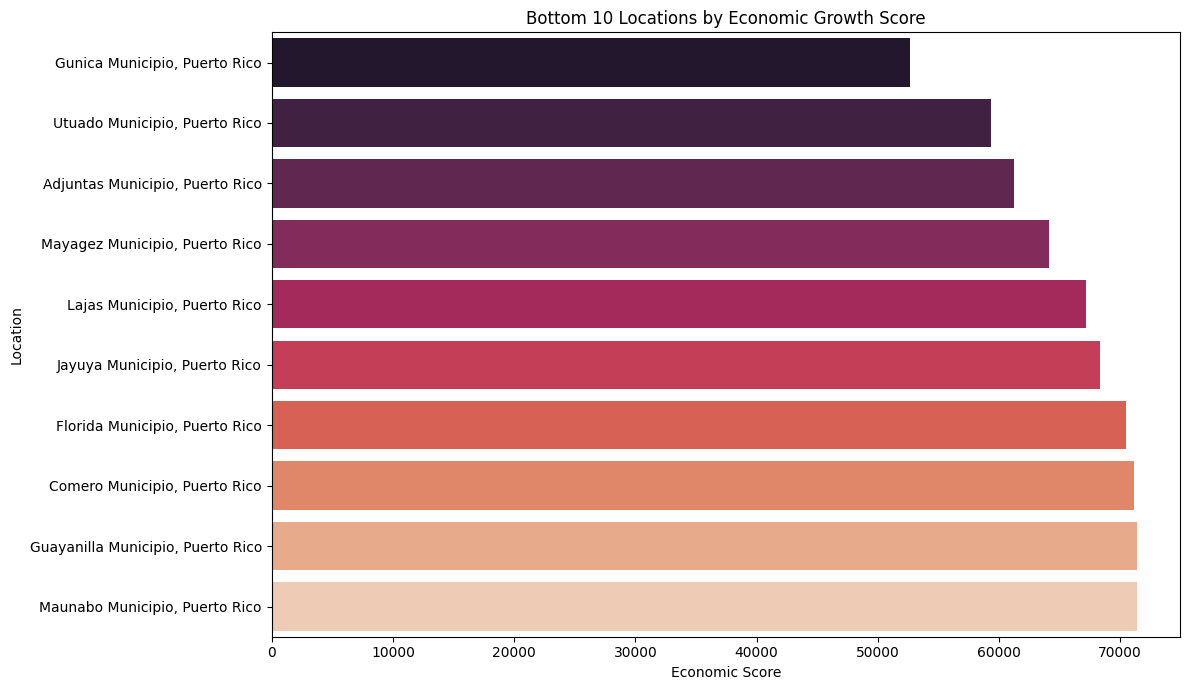

C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\3189926629.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="median_household_income", y="countystate_name", data=low_growth_df, ax=axes[0, 0], palette="flare")
C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\3189926629.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="employment_rate", y="countystate_name", data=low_growth_df, ax=axes[0, 1], palette="mako")
C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\3189926629.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=

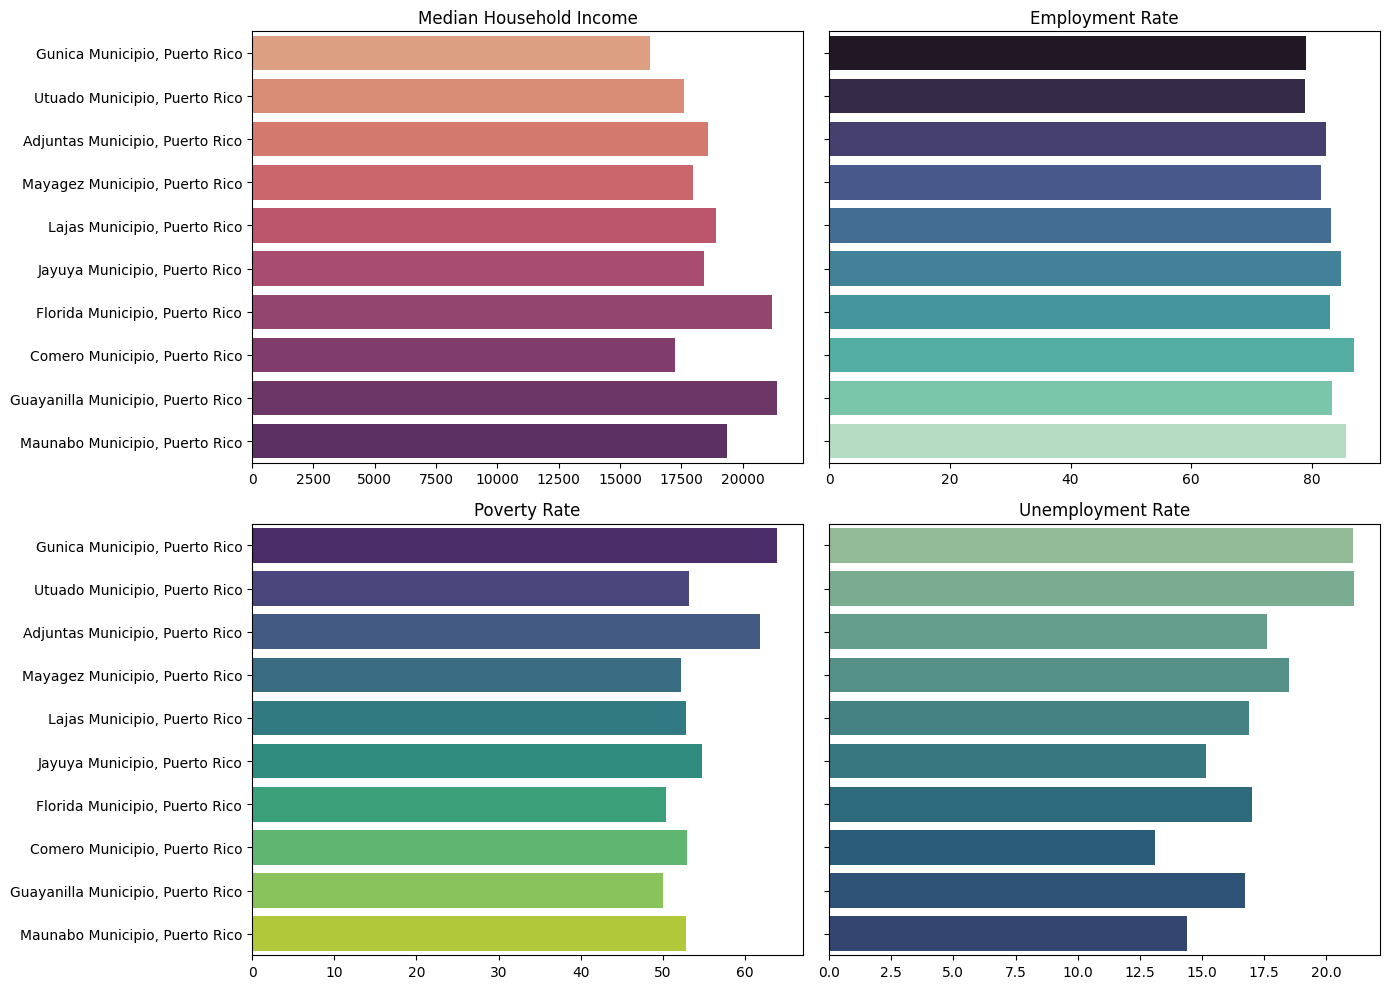

In [33]:
low_growth_df = pd.read_sql(query_growth_trends_low, engine)
low_growth_df = low_growth_df.sort_values("economic_score", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
x="economic_score",
y="countystate_name",
data=low_growth_df,
palette="rocket",
ax=ax
)
ax.set_title("Bottom 10 Locations by Economic Growth Score")
ax.set_xlabel("Economic Score")
ax.set_ylabel("Location")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
sns.barplot(x="median_household_income", y="countystate_name", data=low_growth_df, ax=axes[0, 0], palette="flare")
axes[0, 0].set_title("Median Household Income")
sns.barplot(x="employment_rate", y="countystate_name", data=low_growth_df, ax=axes[0, 1], palette="mako")
axes[0, 1].set_title("Employment Rate")
sns.barplot(x="poverty_rate", y="countystate_name", data=low_growth_df, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Poverty Rate")
sns.barplot(x="unemployment_rate", y="countystate_name", data=low_growth_df, ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Unemployment Rate")

for axis in axes.flatten():
    axis.set_xlabel("")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

#### Does a higher population density correlate with stronger economic activity?

Answer: Densely populated counties does not directly result in higher economic activity or household income

In [35]:
pop_dens_eco_growth = f"""
WITH pop_calc AS (
  SELECT
    population::double precision AS population,
    median_household_income::double precision AS income,
    CASE WHEN population > 0 THEN ln(population) ELSE NULL END AS log_population
  FROM cleaned_us_census_data
)
SELECT
  COUNT(*) FILTER (WHERE population IS NOT NULL AND income IS NOT NULL) AS n_samples,
  corr(population, income)           AS corr_pop_income,
  corr(log_population, income)       AS corr_logpop_income,
  regr_slope(income, population)     AS slope_income_on_pop,
  regr_slope(income, log_population) AS slope_income_on_logpop,
  regr_r2(income, population)        AS r2_income_on_pop
FROM pop_calc
WHERE population IS NOT NULL AND income IS NOT NULL;
"""
pop_dens_eco_growth_df = pd.read_sql(pop_dens_eco_growth, engine)
print("\nRelationship between population density and economic performance - ")
print(pop_dens_eco_growth_df.head())


Relationship between population density and economic performance - 
   n_samples  corr_pop_income  corr_logpop_income  slope_income_on_pop  \
0       3220         0.284639            0.392151             0.015873   

   slope_income_on_logpop  r2_income_on_pop  
0              4806.67351          0.081019  


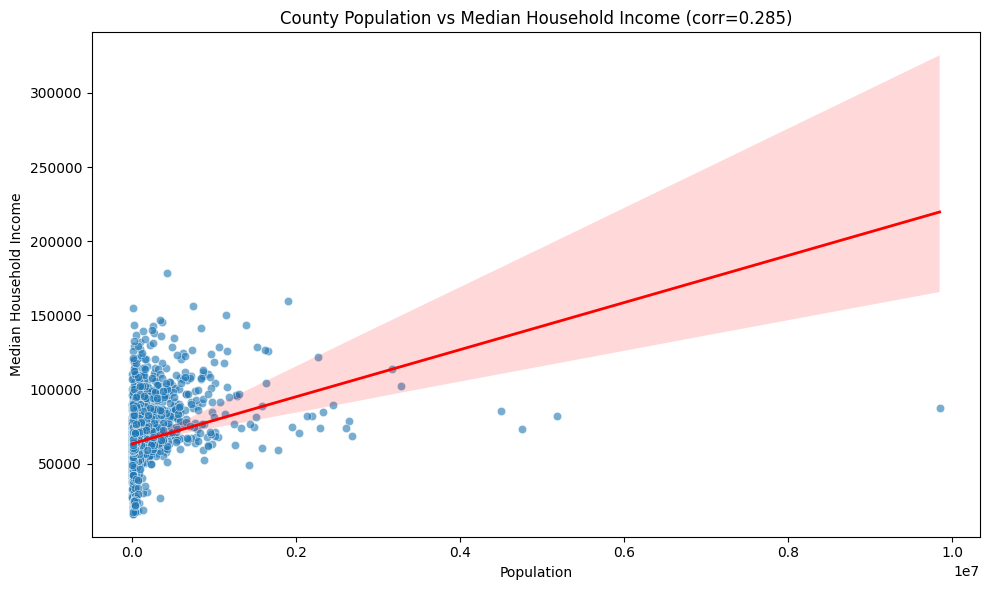

In [39]:
query_pop_income = """
SELECT
population,
median_household_income
FROM cleaned_us_census_data
WHERE population IS NOT NULL
AND median_household_income IS NOT NULL;
"""
pop_income_df = pd.read_sql(query_pop_income, engine)

corr_value = pop_income_df[['population', 'median_household_income']].corr().loc['population', 'median_household_income']

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
x='population',
y='median_household_income',
data=pop_income_df,
alpha=0.6,
ax=ax
)
sns.regplot(
x='population',
y='median_household_income',
data=pop_income_df,
scatter=False,
ax=ax,
color='red',
line_kws={'linewidth': 2}
)
ax.set_title(f'County Population vs Median Household Income (corr={corr_value:.3f})')
ax.set_xlabel('Population')
ax.set_ylabel('Median Household Income')
plt.tight_layout()
plt.show()


#### How do labor force participation rates vary across regions, and what impact do they have on local economies?

Answer: States with higher employment rate has higher average household incomes and stronger local economies

In [41]:
lab_for_corr_eco_growth = f"""
WITH state_region AS (
  SELECT
    split_part(countystate_name, ', ', 2) AS state_name,
    AVG(employment_rate) AS avg_employment_rate,
    AVG(unemployment_rate) AS avg_unemployment_rate,
    AVG(median_household_income) AS avg_median_household_income,
    AVG(poverty_rate) AS avg_poverty_rate,
    COUNT(*) AS county_count
  FROM cleaned_us_census_data
  GROUP BY split_part(countystate_name, ', ', 2)
)
SELECT
  state_name,
  avg_employment_rate,
  avg_unemployment_rate,
  avg_median_household_income,
  avg_poverty_rate,
  county_count
FROM state_region
ORDER BY avg_employment_rate DESC;
"""
lab_corr_eco_growth_df = pd.read_sql(lab_for_corr_eco_growth, engine)
print("\nCorrelation between labor force participation and economic growth - ")
print(lab_corr_eco_growth_df.head())


Correlation between labor force participation and economic growth - 
     state_name  avg_employment_rate  avg_unemployment_rate  \
0      Nebraska            97.877982               2.122018   
1  North Dakota            97.345952               2.654048   
2        Kansas            97.208681               2.791319   
3          Iowa            96.929240               3.070760   
4       Wyoming            96.810407               3.189593   

   avg_median_household_income  avg_poverty_rate  county_count  
0                 66880.387097          9.693369            93  
1                 72537.018868         11.130073            53  
2                 64427.952381         11.077795           105  
3                 69830.030303         10.425502            99  
4                 73360.043478         10.487966            23  


C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\2231614772.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\2231614772.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


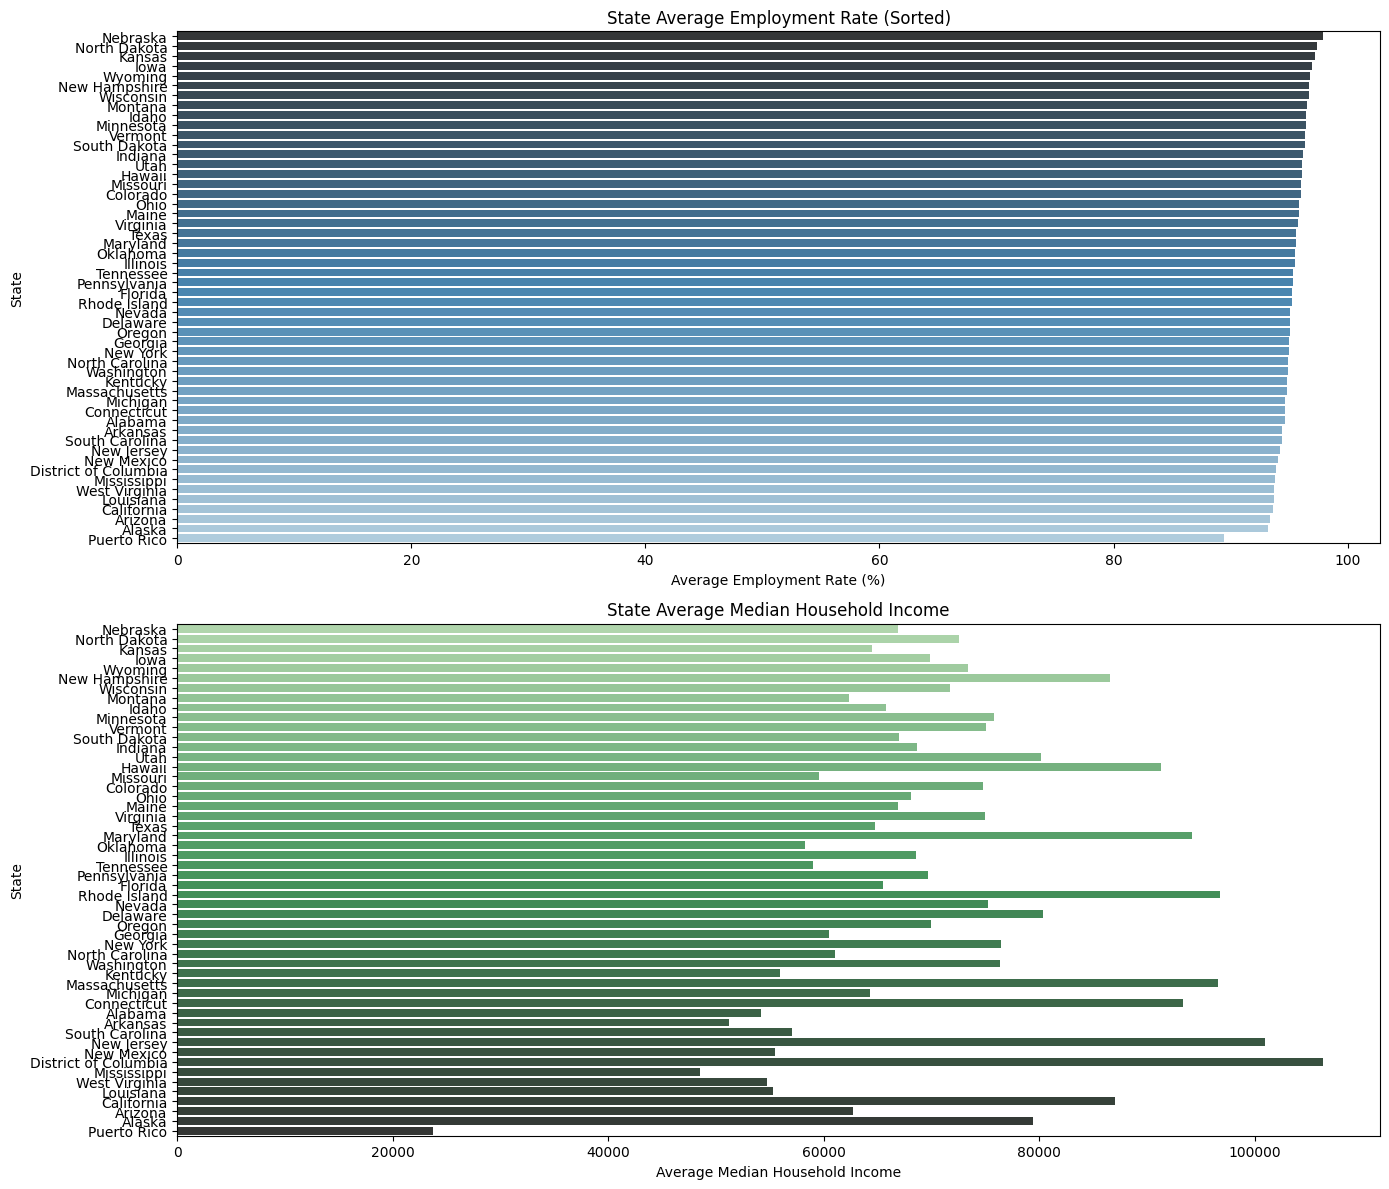

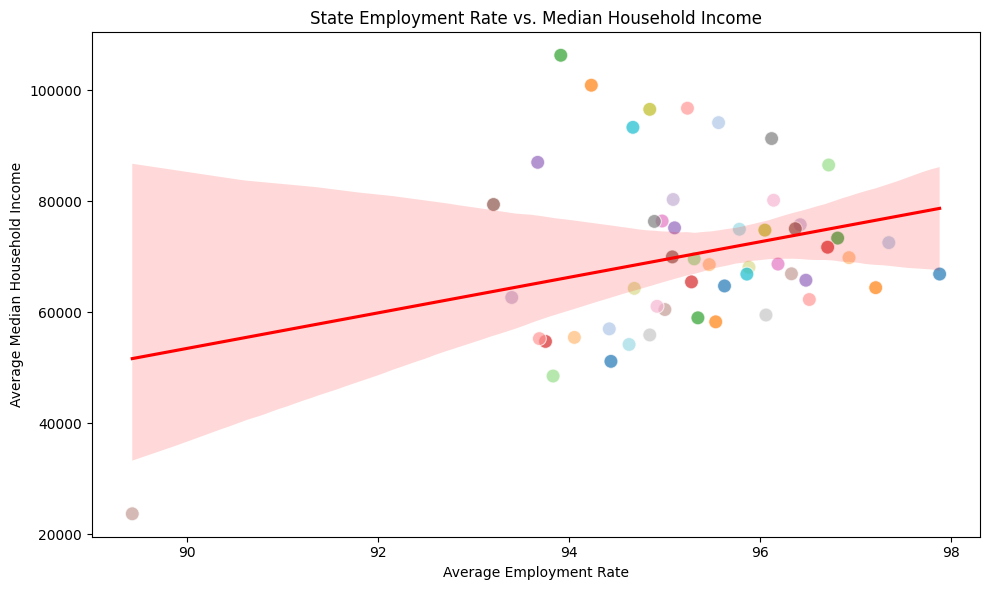


State Labor Force Data:
              state_name  avg_employment_rate  avg_unemployment_rate  \
0               Nebraska            97.877982               2.122018   
1           North Dakota            97.345952               2.654048   
2                 Kansas            97.208681               2.791319   
3                   Iowa            96.929240               3.070760   
4                Wyoming            96.810407               3.189593   
5          New Hampshire            96.716497               3.283503   
6              Wisconsin            96.705540               3.294460   
7                Montana            96.513666               3.486334   
8                  Idaho            96.478046               3.521954   
9              Minnesota            96.418387               3.581613   
10               Vermont            96.367086               3.632914   
11          South Dakota            96.326587               3.673413   
12               Indiana            96.

In [44]:
lab_for_corr_eco_growth = """
WITH state_region AS (
SELECT
split_part(countystate_name, ', ', 2) AS state_name,
AVG(employment_rate) AS avg_employment_rate,
AVG(unemployment_rate) AS avg_unemployment_rate,
AVG(median_household_income) AS avg_median_household_income,
AVG(poverty_rate) AS avg_poverty_rate,
COUNT(*) AS county_count
FROM cleaned_us_census_data
GROUP BY split_part(countystate_name, ', ', 2)
)
SELECT
state_name,
avg_employment_rate,
avg_unemployment_rate,
avg_median_household_income,
avg_poverty_rate,
county_count
FROM state_region
ORDER BY avg_employment_rate DESC;
"""
state_lab_df = pd.read_sql(lab_for_corr_eco_growth, engine)

state_lab_df_clean = state_lab_df[state_lab_df['state_name'].notna()].copy()
state_lab_df_clean = state_lab_df_clean.sort_values('avg_employment_rate', ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(
    y="state_name",
    x="avg_employment_rate",
    data=state_lab_df_clean,
    palette="Blues_d",
    ax=axes[0]
)
axes[0].set_title("State Average Employment Rate (Sorted)")
axes[0].set_xlabel("Average Employment Rate (%)")
axes[0].set_ylabel("State")
axes[0].invert_yaxis()

sns.barplot(
x="avg_median_household_income",
y="state_name",
data=state_lab_df,
palette="Greens_d",
ax=axes[1]
)
axes[1].set_title("State Average Median Household Income")
axes[1].set_xlabel("Average Median Household Income")
axes[1].set_ylabel("State")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
x="avg_employment_rate",
y="avg_median_household_income",
hue="state_name",
palette="tab20",
data=state_lab_df,
legend=False,
s=100,
alpha=0.7,
ax=ax
)
sns.regplot(
x="avg_employment_rate",
y="avg_median_household_income",
data=state_lab_df,
scatter=False,
color="red",
ax=ax
)
ax.set_title("State Employment Rate vs. Median Household Income")
ax.set_xlabel("Average Employment Rate")
ax.set_ylabel("Average Median Household Income")
plt.tight_layout()
plt.show()

print("\nState Labor Force Data:")
print(state_lab_df)
print(f"\nTotal states: {len(state_lab_df)}")
print(f"Null values in state_name: {state_lab_df['state_name'].isna().sum()}")

#### Are counties with higher education levels associated with lower poverty rates?

Answer: There is a strong negative correlation between bachelor's degree attainment and poverty rate. Counties with higher educational attainment have significantly lower poverty rates, suggesting education is a key factor in reducing poverty.

In [45]:
query_education_poverty = f"""
SELECT
  corr(bachelors_degree, poverty_rate) AS corr_education_poverty,
  regr_slope(poverty_rate, bachelors_degree) AS slope_poverty_by_education,
  regr_r2(poverty_rate, bachelors_degree) AS r_squared,
  COUNT(*) AS county_count,
  AVG(bachelors_degree) AS avg_education,
  AVG(poverty_rate) AS avg_poverty,
  MIN(poverty_rate) AS min_poverty,
  MAX(poverty_rate) AS max_poverty
FROM cleaned_us_census_data;
"""

edu_pov_stats = pd.read_sql(query_education_poverty, engine)

print("\nEducation-Poverty Relationship Statistics:")
print(edu_pov_stats.to_string())


Education-Poverty Relationship Statistics:
   corr_education_poverty  slope_poverty_by_education  r_squared  county_count  avg_education  avg_poverty  min_poverty  max_poverty
0                -0.10505                   -0.000014   0.011036          3222   15236.332713    14.462872     1.700437    63.877582


C:\Users\Patrick\AppData\Local\Temp\ipykernel_18124\2036994247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


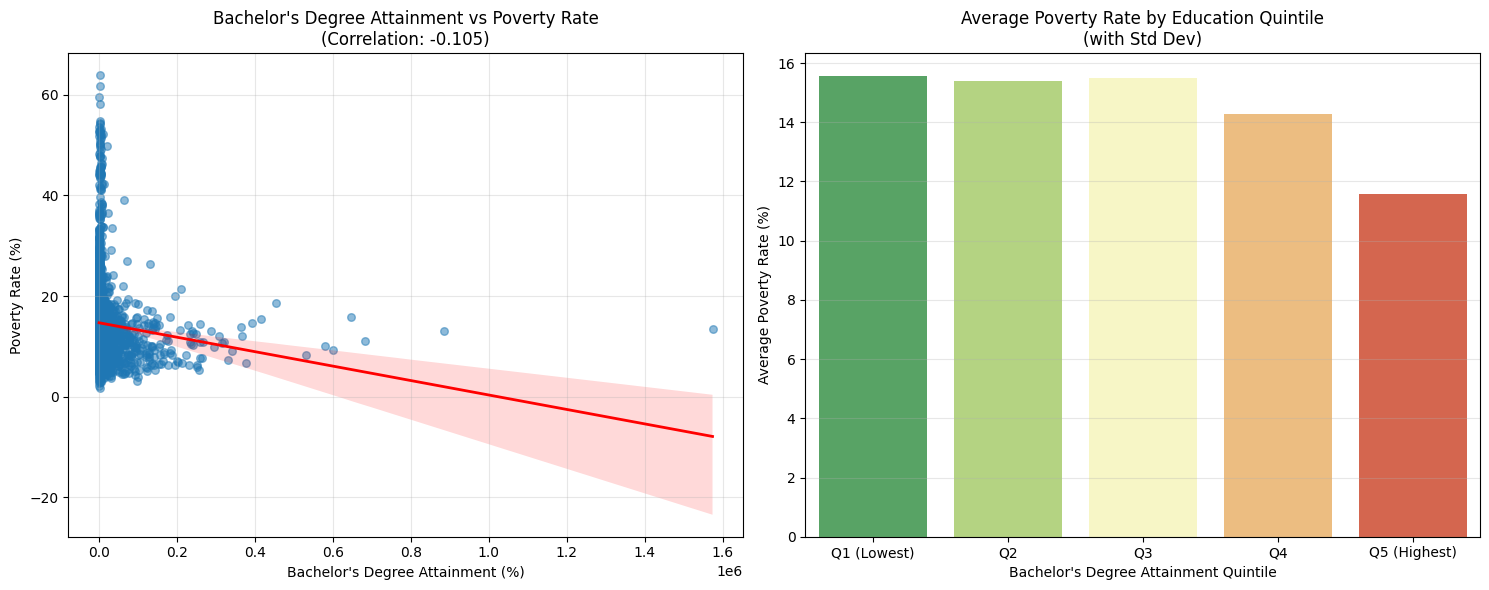


Poverty Rate by Education Quintile:
  education_quintile       mean       std  count
0        Q1 (Lowest)  15.556233  7.946730    646
1                 Q2  15.390814  6.343303    643
2                 Q3  15.494274  8.592469    644
3                 Q4  14.290749  7.881220    644
4       Q5 (Highest)  11.584805  4.975523    645


In [46]:
# Retrieve data for visualization
query_edu_poverty_data = f"""
SELECT
  bachelors_degree,
  poverty_rate,
  countystate_name
FROM cleaned_us_census_data
WHERE bachelors_degree IS NOT NULL
  AND poverty_rate IS NOT NULL
ORDER BY bachelors_degree DESC;
"""

edu_pov_df = pd.read_sql(query_edu_poverty_data, engine)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot with regression line
sns.regplot(
    x='bachelors_degree',
    y='poverty_rate',
    data=edu_pov_df,
    ax=axes[0],
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'red', 'linewidth': 2}
)
corr_value = edu_pov_df[['bachelors_degree', 'poverty_rate']].corr().iloc[0, 1]
axes[0].set_title(f"Bachelor's Degree Attainment vs Poverty Rate\n(Correlation: {corr_value:.3f})")
axes[0].set_xlabel("Bachelor's Degree Attainment (%)")
axes[0].set_ylabel("Poverty Rate (%)")
axes[0].grid(True, alpha=0.3)

# Binned analysis - group by education quintiles
edu_pov_df['education_quintile'] = pd.qcut(edu_pov_df['bachelors_degree'], q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
quintile_analysis = edu_pov_df.groupby('education_quintile', observed=True)['poverty_rate'].agg(['mean', 'std', 'count']).reset_index()

sns.barplot(
    x='education_quintile',
    y='mean',
    data=quintile_analysis,
    palette='RdYlGn_r',
    ax=axes[1],
    errorbar='sd'
)
axes[1].set_title("Average Poverty Rate by Education Quintile\n(with Std Dev)")
axes[1].set_xlabel("Bachelor's Degree Attainment Quintile")
axes[1].set_ylabel("Average Poverty Rate (%)")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nPoverty Rate by Education Quintile:")
print(quintile_analysis.to_string())

#### Which demographic indicators best predict economic prosperity within a state or county?

Answer: 
1. The strongest single predictor of economic prosperity is lower poverty rate.
2. The next most important predictors are higher education levels and higher employment rates.
3. At the state level, average education and average population strengthen as predictors of median income.

In summary, economic prosperity is best predicted by a combination of low poverty and high education, with employment also playing a strong supporting role.

In [47]:
query_demo_corr_econ_growth = f"""
WITH state_avgs AS (
  SELECT
    split_part(countystate_name, ', ', 2) AS state,
    AVG(bachelors_degree) AS avg_bachelors_degree,
    AVG(employment_rate) AS avg_employment_rate,
    AVG(unemployment_rate) AS avg_unemployment_rate,
    AVG(poverty_rate) AS avg_poverty_rate,
    AVG(population) AS avg_population,
    AVG(median_household_income) AS avg_median_household_income
  FROM cleaned_us_census_data
  GROUP BY split_part(countystate_name, ', ', 2)
)
SELECT
  'county' AS level,
  corr(bachelors_degree, median_household_income) AS corr_education_income,
  corr(employment_rate, median_household_income) AS corr_employment_income,
  corr(unemployment_rate, median_household_income) AS corr_unemployment_income,
  corr(poverty_rate, median_household_income) AS corr_poverty_income,
  corr(population, median_household_income) AS corr_population_income
FROM cleaned_us_census_data
UNION ALL
SELECT
  'state' AS level,
  corr(avg_bachelors_degree, avg_median_household_income) AS corr_education_income,
  corr(avg_employment_rate, avg_median_household_income) AS corr_employment_income,
  corr(avg_unemployment_rate, avg_median_household_income) AS corr_unemployment_income,
  corr(avg_poverty_rate, avg_median_household_income) AS corr_poverty_income,
  corr(avg_population, avg_median_household_income) AS corr_population_income
FROM state_avgs;
"""
demo_corr_econ_growth_df = pd.read_sql(query_demo_corr_econ_growth, engine)
print("\nCorrelation between demographic factors and economic growth at county vs state level:")
print(demo_corr_econ_growth_df.to_string(index=False))


Correlation between demographic factors and economic growth at county vs state level:
 level  corr_education_income  corr_employment_income  corr_unemployment_income  corr_poverty_income  corr_population_income
county               0.327477                0.393754                 -0.393754            -0.737475                0.284639
 state               0.679428                0.291726                 -0.291726            -0.729845                0.639177


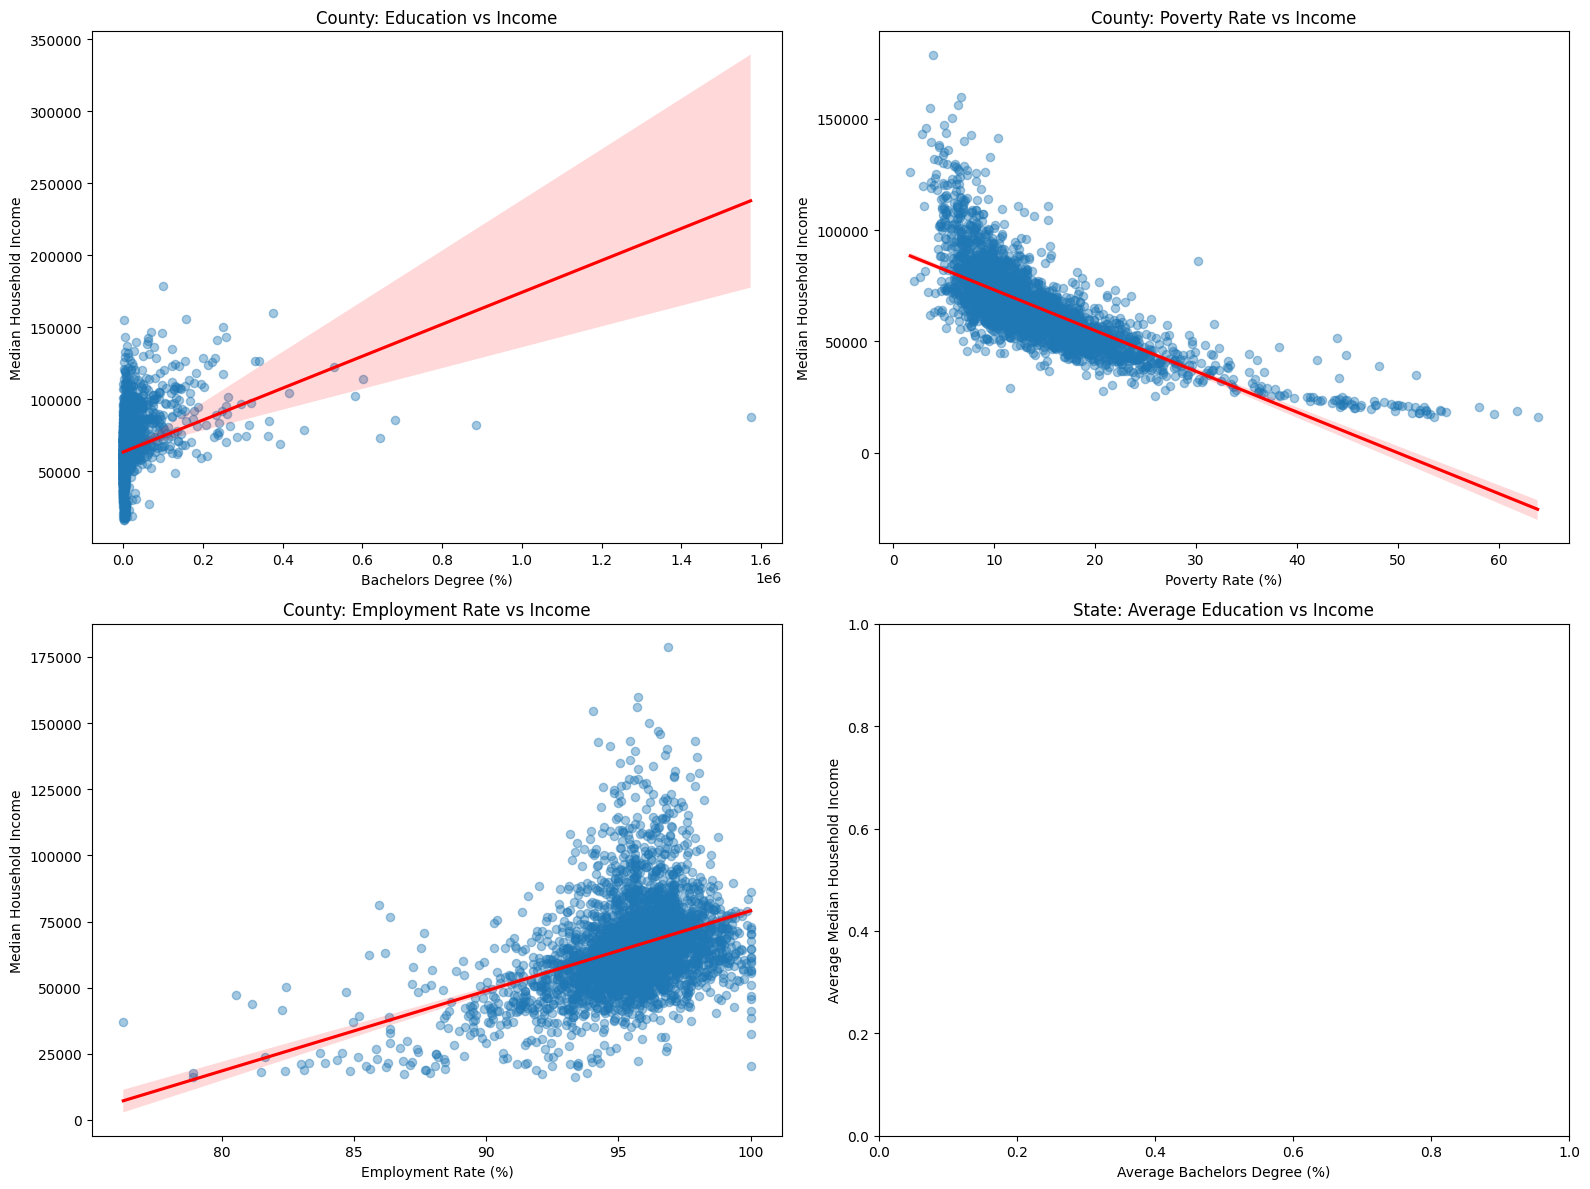

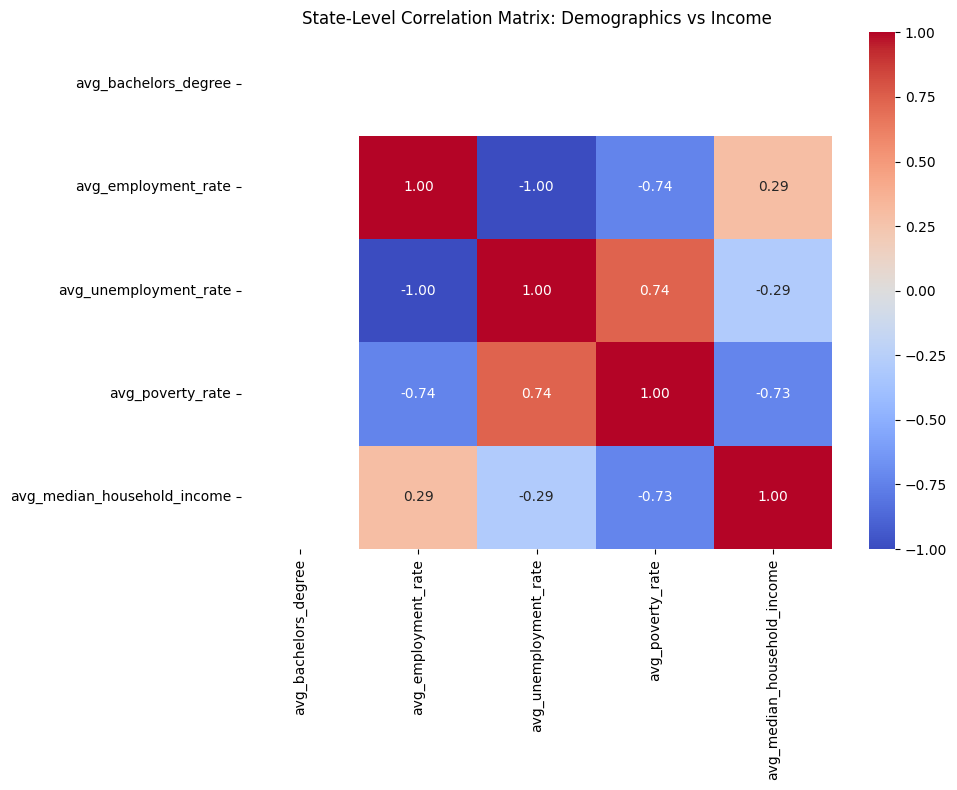

In [49]:
query_demo_trends = f"""
WITH state_avgs AS (
  SELECT
    split_part(countystate_name, ', ', 2) AS state,
    AVG(bachelors_degree) AS avg_bachelors_degree,
    AVG(employment_rate) AS avg_employment_rate,
    AVG(unemployment_rate) AS avg_unemployment_rate,
    AVG(poverty_rate) AS avg_poverty_rate,
    AVG(population) AS avg_population,
    AVG(median_household_income) AS avg_median_household_income
  FROM cleaned_us_census_data
  GROUP BY split_part(countystate_name, ', ', 2)
)
SELECT
  'county' AS level,
  bachelors_degree,
  employment_rate,
  unemployment_rate,
  poverty_rate,
  population,
  median_household_income,
  NULL::text AS state
FROM cleaned_us_census_data
WHERE bachelors_degree IS NOT NULL
  AND median_household_income IS NOT NULL
UNION ALL
SELECT
  'state' AS level,
  NULL::double precision AS bachelors_degree,
  avg_employment_rate AS employment_rate,
  avg_unemployment_rate AS unemployment_rate,
  avg_poverty_rate AS poverty_rate,
  avg_population AS population,
  avg_median_household_income AS median_household_income,
  state
FROM state_avgs;
"""
trend_df = pd.read_sql(query_demo_trends, engine)

county_df = trend_df[trend_df['level'] == 'county'].copy()
state_df = trend_df[trend_df['level'] == 'state'].copy()
state_df = state_df.rename(columns={
    'bachelors_degree': 'avg_bachelors_degree',
    'employment_rate': 'avg_employment_rate',
    'unemployment_rate': 'avg_unemployment_rate',
    'poverty_rate': 'avg_poverty_rate',
    'population': 'avg_population',
    'median_household_income': 'avg_median_household_income'
})

# Plot county-level relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(
    x='bachelors_degree',
    y='median_household_income',
    data=county_df,
    ax=axes[0, 0],
    scatter_kws={'alpha': 0.4, 's': 35},
    line_kws={'color': 'red'}
)
axes[0, 0].set_title("County: Education vs Income")
axes[0, 0].set_xlabel("Bachelors Degree (%)")
axes[0, 0].set_ylabel("Median Household Income")

sns.regplot(
    x='poverty_rate',
    y='median_household_income',
    data=county_df,
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.4, 's': 35},
    line_kws={'color': 'red'}
)
axes[0, 1].set_title("County: Poverty Rate vs Income")
axes[0, 1].set_xlabel("Poverty Rate (%)")
axes[0, 1].set_ylabel("Median Household Income")

sns.regplot(
    x='employment_rate',
    y='median_household_income',
    data=county_df,
    ax=axes[1, 0],
    scatter_kws={'alpha': 0.4, 's': 35},
    line_kws={'color': 'red'}
)
axes[1, 0].set_title("County: Employment Rate vs Income")
axes[1, 0].set_xlabel("Employment Rate (%)")
axes[1, 0].set_ylabel("Median Household Income")

# State-level trend plot
sns.scatterplot(
    x='avg_bachelors_degree',
    y='avg_median_household_income',
    data=state_df,
    hue='state',
    palette='tab20',
    legend=False,
    s=100,
    alpha=0.75,
    ax=axes[1, 1]
)
sns.regplot(
    x='avg_bachelors_degree',
    y='avg_median_household_income',
    data=state_df,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title("State: Average Education vs Income")
axes[1, 1].set_xlabel("Average Bachelors Degree (%)")
axes[1, 1].set_ylabel("Average Median Household Income")

plt.tight_layout()
plt.show()

# Additional bar chart for state-level economic predictors
state_corr = state_df[['avg_bachelors_degree', 'avg_employment_rate', 'avg_unemployment_rate', 'avg_poverty_rate', 'avg_median_household_income']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    state_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('State-Level Correlation Matrix: Demographics vs Income')
plt.tight_layout()
plt.show()